In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
from datetime import datetime, timedelta
import re

# Use TensorFlow's Keras (recommended approach)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow.keras.backend as K

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.19.0
Keras version: 3.9.2


In [2]:
class Hurricane:
    """
    Base class for all hurricane objects with comprehensive analysis capabilities.
    This class defines the interface and shared functionality for both historical 
    and synthetic hurricanes.
    """
    
    def __init__(self, hurricane_id, name, data=None, wind_farm_lat=None, wind_farm_lon=None, turbine_height=150):
        self.hurricane_id = hurricane_id
        self.name = name
        self.data = data if data is not None else pd.DataFrame()
        self.wind_farm_lat = wind_farm_lat
        self.wind_farm_lon = wind_farm_lon  # Fixed typo: was wind_lon
        self.turbine_height = turbine_height
        self._wind_analysis_complete = False
        
    # Core data access methods
    def get_track_data(self):
        """Return hurricane track data"""
        return self.data
    
    def get_max_intensity(self):
        """Return maximum wind speed"""
        if not self.data.empty and 'max_wind' in self.data.columns:
            return self.data['max_wind'].max()
        return None
    
    def get_duration(self):
        """Return hurricane duration in hours"""
        if not self.data.empty and 'datetime' in self.data.columns:
            return (self.data['datetime'].max() - self.data['datetime'].min()).total_seconds() / 3600
        return None
    
    # Wind farm configuration
    def set_wind_farm(self, lat, lon, turbine_height=150):
        """Set wind farm location for analysis"""
        self.wind_farm_lat = lat
        self.wind_farm_lon = lon
        self.turbine_height = turbine_height
        self._wind_analysis_complete = False
        return self
    
    # Core analysis methods - shared by all hurricane types
    def analyze_wind_farm_impact(self):
        """Analyze hurricane impact on wind farm"""
        if self.wind_farm_lat is None or self.wind_farm_lon is None:
            raise ValueError("Wind farm location not set. Use set_wind_farm(lat, lon) first.")
        
        wind_speeds = []
        distances = []
        wind_directions = []
        
        for index, row in self.data.iterrows():
            distance_km = self._haversine_distance(
                self.wind_farm_lat, self.wind_farm_lon, 
                row['latitude'], row['longitude']
            )
            vmax = row['max_wind']  # knots
            rmax = 50  # typical value, can be adjusted
            wind_speed = self._holland_wind_profile(distance_km, vmax, rmax)
            wind_speed_adjusted = self._adjust_wind_speed_to_height(wind_speed)
            wind_direction = self._calculate_wind_direction(
                row['latitude'], row['longitude'], 
                self.wind_farm_lat, self.wind_farm_lon
            )
            
            wind_speeds.append(wind_speed_adjusted)
            distances.append(distance_km)
            wind_directions.append(wind_direction)
        
        self.data = self.data.copy()
        self.data['distance_km'] = distances
        self.data['wind_speed'] = wind_speeds
        self.data['wind_direction'] = wind_directions
        self._wind_analysis_complete = True
        
        return self
    
    def get_wind_farm_summary(self):
        """Get summary of wind farm impact"""
        if not self._wind_analysis_complete:
            raise ValueError("Wind farm analysis not complete. Run analyze_wind_farm_impact() first.")
        
        closest_approach = self.data['distance_km'].min()
        max_wind_at_farm = self.data['wind_speed'].max()
        arrival_time = None
        
        # Find arrival time (within 500km)
        close_records = self.data[self.data['distance_km'] <= 500]
        if not close_records.empty:
            arrival_time = close_records['datetime'].min()
        
        summary = {
            'closest_approach_km': closest_approach,
            'max_wind_speed_knots': max_wind_at_farm,
            'arrival_time': arrival_time,
            'max_intensity_knots': self.get_max_intensity(),
            'duration_hours': self.get_duration(),
            'exceeds_cutout': max_wind_at_farm > 48.6 if max_wind_at_farm else False
        }
        
        return summary
    
    # Visualization methods - shared by all hurricane types
    def plot(self, show_wind_farm=True, figsize=(14, 10), extent=None):
        """Plot hurricane track with realistic base map"""
        fig = plt.figure(figsize=figsize)
        ax = plt.axes(projection=ccrs.PlateCarree())
        
        # Add realistic base map features with proper styling
        ax.add_feature(cfeature.LAND, color='lightgray', alpha=0.8)
        ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.6)
        ax.add_feature(cfeature.COASTLINE, linewidth=1.0, color='black')
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.7, color='gray')
        ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.7, color='darkgray')
        ax.add_feature(cfeature.LAKES, color='lightblue', alpha=0.7)
        ax.add_feature(cfeature.RIVERS, color='blue', alpha=0.5, linewidth=0.5)
        
        # Set extent with proper margins
        if extent is None and not self.data.empty:
            lat_margin = max(2, (self.data['latitude'].max() - self.data['latitude'].min()) * 0.15)
            lon_margin = max(2, (self.data['longitude'].max() - self.data['longitude'].min()) * 0.15)
            extent = [
                self.data['longitude'].min() - lon_margin,
                self.data['longitude'].max() + lon_margin,
                self.data['latitude'].min() - lat_margin,
                self.data['latitude'].max() + lat_margin
            ]
            ax.set_extent(extent, crs=ccrs.PlateCarree())
        
        if not self.data.empty:
            # Get hurricane type-specific styling
            line_color, line_style, line_width = self._get_plot_style()
            
            # Plot track line with proper styling
            ax.plot(self.data['longitude'], self.data['latitude'], 
                   color=line_color, linewidth=line_width, alpha=0.8, linestyle=line_style,
                   transform=ccrs.PlateCarree(), zorder=3)
            
            # Plot intensity-colored points with better styling
            if 'max_wind' in self.data.columns:
                scatter = ax.scatter(self.data['longitude'], self.data['latitude'], 
                                   c=self.data['max_wind'], cmap='YlOrRd', s=50,
                                   alpha=0.9, edgecolors='darkred', linewidths=0.8,
                                   transform=ccrs.PlateCarree(), zorder=4)
                
                # Add colorbar with better positioning
                cbar = plt.colorbar(scatter, ax=ax, shrink=0.8, pad=0.02)
                cbar.set_label('Wind Speed (knots)', fontsize=12)
                cbar.ax.tick_params(labelsize=10)
        
        # Add wind farm location with enhanced styling
        if show_wind_farm and self.wind_farm_lat is not None and self.wind_farm_lon is not None:
            ax.scatter(self.wind_farm_lon, self.wind_farm_lat, 
                      color='black', marker='*', s=400, 
                      label='Wind Farm', transform=ccrs.PlateCarree(),
                      zorder=10, edgecolors='white', linewidths=2)
        
        # Add gridlines with proper styling
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.6, linestyle='--', color='gray')
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'size': 10}
        gl.ylabel_style = {'size': 10}
        
        # Add title and legend with better formatting
        title = self._get_plot_title()
        plt.title(title, fontsize=16, fontweight='bold', pad=20)
        
        if show_wind_farm and self.wind_farm_lat is not None:
            plt.legend(loc='upper right', fontsize=12, framealpha=0.9)
        
        plt.tight_layout()
        plt.show()
        
        return fig, ax
    
    def plot_wind_field(self, rmax=50, B=1.5, figsize=(12, 10)):
        """Plot hurricane wind field with realistic base map"""
        if self.data.empty:
            raise ValueError("No hurricane data available")
        
        if self.wind_farm_lat is None or self.wind_farm_lon is None:
            raise ValueError("Wind farm location not set. Use set_wind_farm(lat, lon) first.")
        
        # Use center point of hurricane
        lat_center = self.data['latitude'].iloc[0]
        lon_center = self.data['longitude'].iloc[0]
        max_wind = self.data['max_wind'].iloc[0]
        
        # Create grid
        lat_range = np.linspace(lat_center - 10, lat_center + 10, 200)
        lon_range = np.linspace(lon_center - 10, lon_center + 10, 200)
        lat_grid, lon_grid = np.meshgrid(lat_range, lon_range)
        
        # Calculate wind speeds
        wind_speeds = np.zeros_like(lat_grid)
        for i in range(lat_grid.shape[0]):
            for j in range(lat_grid.shape[1]):
                distance_km = self._haversine_distance(
                    lat_center, lon_center, lat_grid[i, j], lon_grid[i, j]
                )
                wind_speeds[i, j] = self._holland_wind_profile(distance_km, max_wind, rmax, B)
        
        # Plot with realistic base map
        fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': ccrs.PlateCarree()})
        
        # Add realistic base map features
        ax.add_feature(cfeature.LAND, color='lightgray', alpha=0.8)
        ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.6)
        ax.add_feature(cfeature.COASTLINE, linewidth=1.0, color='black')
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.7, color='gray')
        ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.7, color='darkgray')
        ax.add_feature(cfeature.LAKES, color='lightblue', alpha=0.7)
        ax.add_feature(cfeature.RIVERS, color='blue', alpha=0.5, linewidth=0.5)
        
        # Plot wind field
        contour = ax.contourf(lon_grid, lat_grid, wind_speeds, 
                            levels=np.linspace(0, max_wind, 20), 
                            cmap='YlOrRd', transform=ccrs.PlateCarree(), alpha=0.7)
        cbar = plt.colorbar(contour, ax=ax, shrink=0.8, pad=0.02)
        cbar.set_label('Wind Speed (knots)', fontsize=12)
        cbar.ax.tick_params(labelsize=10)
        
        # Plot hurricane track with enhanced styling
        ax.plot(self.data['longitude'], self.data['latitude'], 
               color='blue', linewidth=2.5, alpha=0.9, 
               label='Hurricane Track', transform=ccrs.PlateCarree(), zorder=5)
        
        # Plot wind farm with enhanced styling
        ax.scatter(self.wind_farm_lon, self.wind_farm_lat, 
                  color='black', marker='*', s=400, label='Wind Farm', 
                  transform=ccrs.PlateCarree(), zorder=10,
                  edgecolors='white', linewidths=2)
        
        # Add gridlines
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.6, linestyle='--', color='gray')
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'size': 10}
        gl.ylabel_style = {'size': 10}
        
        ax.set_title(f'Hurricane {self.name} Wind Field', fontsize=16, fontweight='bold', pad=20)
        ax.legend(loc='upper right', fontsize=12, framealpha=0.9)
        plt.tight_layout()
        plt.show()
        
        return fig, ax
    
    # Report generation
    def generate_report(self, output_file=None, cut_out_speed=48.6, arrival_distance_threshold=500):
        """Generate comprehensive hurricane report"""
        if not self._wind_analysis_complete:
            raise ValueError("Wind farm analysis not complete. Run analyze_wind_farm_impact() first.")
        
        if output_file is None:
            output_file = f'hurricane_report_{self.hurricane_id}.csv'
        
        hurricane_data = self.data.copy()
        
        if hurricane_data.empty:
            print("No hurricane data to generate a report.")
            return
        
        # Add type-specific metadata
        hurricane_data = self._add_report_metadata(hurricane_data)
        
        # Calculate arrival time
        arrival_time = hurricane_data.loc[
            hurricane_data['distance_km'] <= arrival_distance_threshold, 'datetime'
        ].min()
        hurricane_data['Arrival_Time'] = arrival_time
        
        # Convert wind speeds from knots to m/s
        hurricane_data['wind_speed_ms'] = hurricane_data['wind_speed'] * 0.514444
        hurricane_data['max_wind_ms'] = hurricane_data['max_wind'] * 0.514444
        
        # Calculate rates of change
        hurricane_data['wind_speed_change_rate'] = (
            hurricane_data['wind_speed_ms'].diff() / 
            hurricane_data['datetime'].diff().dt.total_seconds() * 3600
        ).fillna(0)
        
        hurricane_data['wind_direction_change_rate'] = (
            hurricane_data['wind_direction'].diff() / 
            hurricane_data['datetime'].diff().dt.total_seconds() * 3600
        ).fillna(0)
        
        # Calculate duration above cut-out speed
        cut_out_speed_mps = cut_out_speed * 0.514444
        hurricane_data['above_cut_out'] = hurricane_data['wind_speed_ms'] > cut_out_speed_mps
        hurricane_data['duration_above_cut_out'] = (
            hurricane_data['above_cut_out'].cumsum() * 
            (hurricane_data['datetime'].diff().dt.total_seconds() / 3600).fillna(0)
        )
        
        # Calculate additional parameters
        hurricane_data['category'] = hurricane_data['max_wind'].apply(self._classify_hurricane)
        hurricane_data['quadrant'] = hurricane_data.apply(
            lambda row: self._determine_quadrant(
                row['latitude'], row['longitude'], 
                self.wind_farm_lat, self.wind_farm_lon
            ), axis=1
        )
        
        # Get report columns based on hurricane type
        report_columns = self._get_report_columns()
        
        # Export the report
        hurricane_data[report_columns].to_csv(output_file, index=False)
        print(f"Hurricane report generated and saved to {output_file}")
        return output_file
    
    def print_summary(self):
        """Print a formatted summary of hurricane information"""
        print(f"\n{'='*50}")
        print(f"Hurricane {self.name} ({self.hurricane_id})")
        print(f"Type: {self.get_hurricane_type()}")
        
        # Add type-specific summary information
        self._print_type_specific_info()
        
        print(f"{'='*50}")
        
        if not self.data.empty:
            print(f"Duration: {self.get_duration():.1f} hours")
            print(f"Max Intensity: {self.get_max_intensity()} knots")
            print(f"Data Points: {len(self.data)}")
            
            if self._wind_analysis_complete:
                summary = self.get_wind_farm_summary()
                print(f"\nWind Farm Impact:")
                print(f"  Closest Approach: {summary['closest_approach_km']:.1f} km")
                print(f"  Max Wind at Farm: {summary['max_wind_speed_knots']:.1f} knots")
                if summary['arrival_time']:
                    print(f"  Arrival Time: {summary['arrival_time']}")
                if summary['exceeds_cutout']:
                    print(f"  ⚠️  WARNING: Exceeds typical turbine cut-out speed!")
            else:
                print(f"\nWind farm analysis not performed. Use analyze_wind_farm_impact() method.")
        
        print(f"{'='*50}")
    
    # Abstract methods to be implemented by subclasses
    def get_hurricane_type(self):
        """Return the type of hurricane (to be implemented by subclasses)"""
        raise NotImplementedError("Subclasses must implement get_hurricane_type()")
    
    def _get_plot_style(self):
        """Return plot styling (color, linestyle, linewidth) for this hurricane type"""
        raise NotImplementedError("Subclasses must implement _get_plot_style()")
    
    def _get_plot_title(self):
        """Return plot title for this hurricane type"""
        raise NotImplementedError("Subclasses must implement _get_plot_title()")
    
    def _add_report_metadata(self, hurricane_data):
        """Add type-specific metadata to report (to be implemented by subclasses)"""
        raise NotImplementedError("Subclasses must implement _add_report_metadata()")
    
    def _get_report_columns(self):
        """Return list of columns for report (to be implemented by subclasses)"""
        raise NotImplementedError("Subclasses must implement _get_report_columns()")
    
    def _print_type_specific_info(self):
        """Print type-specific information in summary (to be implemented by subclasses)"""
        raise NotImplementedError("Subclasses must implement _print_type_specific_info()")
    
    # Private helper methods - shared by all hurricane types
    def _haversine_distance(self, lat1, lon1, lat2, lon2):
        """Calculate haversine distance between two points"""
        from math import radians, sin, cos, sqrt, atan2
        lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1-a))
        return 6371 * c  # Earth radius in km
    
    def _holland_wind_profile(self, r, vmax, rmax, B=1.5):
        """Calculate wind speed using Holland wind profile"""
        if r == 0:
            return vmax
        return vmax * (rmax/r)**B * np.exp(1 - (rmax/r)**B)
    
    def _calculate_wind_direction(self, lat1, lon1, lat2, lon2):
        """Calculate wind direction"""
        from math import atan2, degrees
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        angle = atan2(dlat, dlon)
        return (degrees(angle) + 360) % 360
    
    def _adjust_wind_speed_to_height(self, wind_speed, reference_height=10, alpha=0.14):
        """Adjust wind speed to turbine height"""
        return wind_speed * (self.turbine_height / reference_height) ** alpha
    
    def _classify_hurricane(self, vmax):
        """Classify hurricane based on Saffir-Simpson scale"""
        if vmax < 34:
            return "Tropical Depression"
        elif vmax < 64:
            return "Tropical Storm"
        elif vmax < 83:
            return "Category 1"
        elif vmax < 96:
            return "Category 2"
        elif vmax < 113:
            return "Category 3"
        elif vmax < 137:
            return "Category 4"
        else:
            return "Category 5"
    
    def _determine_quadrant(self, lat1, lon1, lat2, lon2):
        """Determine quadrant relative to wind farm"""
        lat_diff = lat2 - lat1
        lon_diff = lon2 - lon1
        if lat_diff > 0 and lon_diff > 0:
            return "NE"
        elif lat_diff > 0 and lon_diff < 0:
            return "NW"
        elif lat_diff < 0 and lon_diff > 0:
            return "SE"
        else:
            return "SW"


class HistoricalHurricane(Hurricane):
    """Subclass for historical hurricanes from HURDAT2 data"""
    
    def __init__(self, hurricane_id, name, hurdat_data, wind_farm_lat=None, wind_farm_lon=None, turbine_height=150):
        super().__init__(hurricane_id, name, hurdat_data, wind_farm_lat, wind_farm_lon, turbine_height)
    
    @classmethod
    def from_hurdat_data(cls, hurdat_df, storm_id, wind_farm_lat=None, wind_farm_lon=None, turbine_height=150):
        """Create HistoricalHurricane from HURDAT2 dataframe"""
        hurricane_data = hurdat_df[hurdat_df['full_id'] == storm_id].copy()
        if not hurricane_data.empty:
            name = hurricane_data['storm_name'].iloc[0]
            return cls(storm_id, name, hurricane_data, wind_farm_lat, wind_farm_lon, turbine_height)
        return None
    
    # Implement abstract methods
    def get_hurricane_type(self):
        return "Historical"
    
    def _get_plot_style(self):
        return 'red', '-', 2.5  # color, linestyle, linewidth
    
    def _get_plot_title(self):
        return f"Hurricane {self.name} ({self.hurricane_id}) - Historical"
    
    def _add_report_metadata(self, hurricane_data):
        """Add historical hurricane metadata to report"""
        hurricane_data = hurricane_data.copy()
        if 'min_pressure' in hurricane_data.columns:
            hurricane_data = hurricane_data.rename(columns={'min_pressure': 'pressure'})
        
        hurricane_data['Hurricane_ID'] = self.hurricane_id
        hurricane_data['Hurricane_Name'] = self.name
        hurricane_data['Hurricane_Type'] = self.get_hurricane_type()
        
        return hurricane_data
    
    def _get_report_columns(self):
        """Return report columns for historical hurricanes"""
        return [
            'Hurricane_ID', 'Hurricane_Name', 'Hurricane_Type',
            'datetime', 'distance_km', 'Arrival_Time',
            'wind_speed_ms', 'wind_direction', 'max_wind_ms',
            'category', 'pressure', 'wind_speed_change_rate',
            'wind_direction_change_rate', 'duration_above_cut_out', 'quadrant'
        ]
    
    def _print_type_specific_info(self):
        """Print historical hurricane specific information"""
        pass  # No additional info for historical hurricanes


class SyntheticHurricane(Hurricane):
    """Subclass for synthetically generated hurricanes"""
    
    def __init__(self, hurricane_id, name, synthetic_data, seed_hurricane_id=None, wind_farm_lat=None, wind_farm_lon=None, turbine_height=150):
        super().__init__(hurricane_id, name, synthetic_data, wind_farm_lat, wind_farm_lon, turbine_height)
        self.seed_hurricane_id = seed_hurricane_id
    
    @classmethod
    def from_lstm_vae_generation(cls, seed_hurricane, lstm_vae_model, hurricane_id=None, name=None, wind_farm_lat=None, wind_farm_lon=None, turbine_height=150):
        """Generate synthetic hurricane using LSTM-VAE"""
        if hurricane_id is None:
            hurricane_id = f"SYN_{seed_hurricane.hurricane_id}_{np.random.randint(1000, 9999)}"
        if name is None:
            name = f"SYNTHETIC_{seed_hurricane.name}"
        
        synthetic_data = lstm_vae_model.generate_synthetic_hurricane(seed_hurricane.data)
        return cls(hurricane_id, name, synthetic_data, seed_hurricane.hurricane_id, wind_farm_lat, wind_farm_lon, turbine_height)
    
    # Implement abstract methods
    def get_hurricane_type(self):
        return "Synthetic"
    
    def _get_plot_style(self):
        return 'blue', '--', 2.0  # color, linestyle, linewidth
    
    def _get_plot_title(self):
        return f"Hurricane {self.name} ({self.hurricane_id}) - Synthetic"
    
    def _add_report_metadata(self, hurricane_data):
        """Add synthetic hurricane metadata to report"""
        hurricane_data = hurricane_data.copy()
        if 'min_pressure' in hurricane_data.columns:
            hurricane_data = hurricane_data.rename(columns={'min_pressure': 'pressure'})
        
        hurricane_data['Hurricane_ID'] = self.hurricane_id
        hurricane_data['Hurricane_Name'] = self.name
        hurricane_data['Hurricane_Type'] = self.get_hurricane_type()
        hurricane_data['Seed_Hurricane_ID'] = self.seed_hurricane_id
        
        return hurricane_data
    
    def _get_report_columns(self):
        """Return report columns for synthetic hurricanes"""
        return [
            'Hurricane_ID', 'Hurricane_Name', 'Hurricane_Type', 'Seed_Hurricane_ID',
            'datetime', 'distance_km', 'Arrival_Time',
            'wind_speed_ms', 'wind_direction', 'max_wind_ms',
            'category', 'pressure', 'wind_speed_change_rate',
            'wind_direction_change_rate', 'duration_above_cut_out', 'quadrant'
        ]
    
    def _print_type_specific_info(self):
        """Print synthetic hurricane specific information"""
        if self.seed_hurricane_id:
            print(f"Based on seed hurricane: {self.seed_hurricane_id}")


class LSTM_VAE:
    """
    LSTM-Variational Autoencoder for generating synthetic hurricane tracks.
    Uses sequence-to-sequence architecture with variational bottleneck.
    """
    
    def __init__(self, input_dim=6, latent_dim=32, lstm_units=64, sequence_length=24):
        self.input_dim = input_dim  # Features: lat, lon, max_wind, pressure, forward_speed, direction
        self.latent_dim = latent_dim
        self.lstm_units = lstm_units
        self.sequence_length = sequence_length
        self.model = None
        self.encoder = None
        self.decoder = None
        self.scaler = StandardScaler()
        self.is_trained = False
        self.training_history = None
        self.live_plot = True  # Enable live plotting
    
    def _haversine_distance(self, lat1, lon1, lat2, lon2):
        """Calculate haversine distance between two points"""
        from math import radians, sin, cos, sqrt, atan2
        
        try:
            lat1, lon1, lat2, lon2 = map(radians, [float(lat1), float(lon1), float(lat2), float(lon2)])
            dlon = lon2 - lon1
            dlat = lat2 - lat1
            a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
            c = 2 * atan2(sqrt(a), sqrt(1-a))
            return 6371 * c  # Earth radius in km
        except:
            return 0.0
        
    def build_model(self):
        """Build the LSTM-VAE architecture"""
        # Clear any existing models
        tf.keras.backend.clear_session()
        
        # Custom sampling layer with proper output shape
        class SamplingLayer(layers.Layer):
            def __init__(self, latent_dim, **kwargs):
                super(SamplingLayer, self).__init__(**kwargs)
                self.latent_dim = latent_dim
                
            def call(self, inputs):
                z_mean, z_log_var = inputs
                batch_size = tf.shape(z_mean)[0]
                epsilon = tf.random.normal(shape=(batch_size, self.latent_dim))
                return z_mean + tf.exp(0.5 * z_log_var) * epsilon
            
            def compute_output_shape(self, input_shape):
                return (input_shape[0][0], self.latent_dim)
            
            def get_config(self):
                config = super(SamplingLayer, self).get_config()
                config.update({'latent_dim': self.latent_dim})
                return config
        
        # Input layer
        encoder_inputs = keras.Input(shape=(self.sequence_length, self.input_dim), name='encoder_input')
        
        # Encoder LSTM layers
        encoder_lstm1 = layers.LSTM(self.lstm_units, return_sequences=True, name='encoder_lstm1')
        encoder_lstm2 = layers.LSTM(self.lstm_units, return_state=True, name='encoder_lstm2')
        
        x = encoder_lstm1(encoder_inputs)
        encoder_outputs, state_h, state_c = encoder_lstm2(x)
        
        # Variational layers
        z_mean = layers.Dense(self.latent_dim, activation='linear', name='z_mean')(encoder_outputs)
        z_log_var = layers.Dense(self.latent_dim, activation='linear', name='z_log_var')(encoder_outputs)
        
        # Sampling layer
        z = SamplingLayer(self.latent_dim, name='z_sampling')([z_mean, z_log_var])
        
        # Decoder
        # Project latent vector to initial decoder state
        decoder_state_h = layers.Dense(self.lstm_units, activation='tanh', name='decoder_state_h')(z)
        decoder_state_c = layers.Dense(self.lstm_units, activation='tanh', name='decoder_state_c')(z)
        
        # Decoder input (start with zeros)
        decoder_inputs = layers.RepeatVector(self.sequence_length, name='decoder_inputs')(z)
        
        # Decoder LSTM layers
        decoder_lstm1 = layers.LSTM(self.lstm_units, return_sequences=True, name='decoder_lstm1')
        decoder_lstm2 = layers.LSTM(self.lstm_units, return_sequences=True, name='decoder_lstm2')
        
        x = decoder_lstm1(decoder_inputs, initial_state=[state_h, state_c])
        decoder_outputs = decoder_lstm2(x)
        
        # Output layer
        decoder_dense = layers.Dense(self.input_dim, activation='linear', name='decoder_output')
        final_outputs = decoder_dense(decoder_outputs)
        
        # Build the full model
        self.model = keras.Model(encoder_inputs, final_outputs, name='lstm_vae')
        
        # Build encoder model for inference
        self.encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')
        
        # Build decoder model for generation
        latent_input = keras.Input(shape=(self.latent_dim,), name='latent_input')
        state_h_input = keras.Input(shape=(self.lstm_units,), name='state_h_input')
        state_c_input = keras.Input(shape=(self.lstm_units,), name='state_c_input')
        
        decoder_state_h_gen = layers.Dense(self.lstm_units, activation='tanh', name='decoder_state_h_gen')(latent_input)
        decoder_state_c_gen = layers.Dense(self.lstm_units, activation='tanh', name='decoder_state_c_gen')(latent_input)
        
        decoder_inputs_gen = layers.RepeatVector(self.sequence_length, name='decoder_inputs_gen')(latent_input)
        
        # Reuse decoder layers
        x_gen = decoder_lstm1(decoder_inputs_gen, initial_state=[decoder_state_h_gen, decoder_state_c_gen])
        decoder_outputs_gen = decoder_lstm2(x_gen)
        final_outputs_gen = decoder_dense(decoder_outputs_gen)
        
        self.decoder = keras.Model(latent_input, final_outputs_gen, name='decoder')
        
        # Custom VAE loss function
        def vae_loss(y_true, y_pred):
            reconstruction_loss = tf.reduce_mean(tf.square(y_true - y_pred))
            kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            return reconstruction_loss + 0.01 * kl_loss  # Beta = 0.01 for KL term
        
        # Compile with custom loss
        self.model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss=vae_loss,
            metrics=['mse']
        )
        
        # Store references for VAE loss calculation
        self.z_mean = z_mean
        self.z_log_var = z_log_var
        
        print("Enhanced LSTM-VAE model architecture built successfully!")
        print(f"Model parameters: {self.model.count_params():,}")
        return self
    
    def prepare_training_data(self, hurricane_data_list):
        """Prepare hurricane data for training with adaptive sequence length"""
        sequences = []
        
        print(f"Processing {len(hurricane_data_list)} hurricanes...")
        
        # First pass: determine optimal sequence length based on data
        lengths = []
        for hurricane_data in hurricane_data_list:
            if len(hurricane_data) >= 8:  # Minimum viable hurricane length
                lengths.append(len(hurricane_data))
        
        if lengths:
            # Use median length, but cap at reasonable bounds
            optimal_length = int(np.median(lengths))
            self.sequence_length = max(12, min(optimal_length, 48))  # Between 12 and 48 time steps
            print(f"Adjusted sequence length to {self.sequence_length} based on data")
        
        for i, hurricane_data in enumerate(hurricane_data_list):
            if len(hurricane_data) < self.sequence_length:
                continue
                
            # Extract features
            try:
                features = self._extract_features(hurricane_data)
                
                # Create multiple overlapping sequences from each hurricane
                for j in range(0, len(features) - self.sequence_length + 1, self.sequence_length // 4):
                    sequence = features[j:j + self.sequence_length]
                    if len(sequence) == self.sequence_length:
                        sequences.append(sequence)
                    
            except Exception as e:
                print(f"Error processing hurricane {i}: {e}")
                continue
        
        if not sequences:
            raise ValueError("No valid sequences found for training")
        
        print(f"Created {len(sequences)} training sequences of length {self.sequence_length}")
        
        # Convert to numpy array and normalize
        X = np.array(sequences, dtype=np.float32)
        
        # Handle any NaN or infinite values
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        
        # Reshape for scaling
        original_shape = X.shape
        X_reshaped = X.reshape(-1, X.shape[-1])
        
        # Fit and transform
        X_scaled = self.scaler.fit_transform(X_reshaped)
        X_scaled = X_scaled.reshape(original_shape)
        
        print(f"Training data shape: {X_scaled.shape}")
        print(f"Feature ranges after scaling: min={X_scaled.min():.3f}, max={X_scaled.max():.3f}")
        return X_scaled
    
    def _extract_features(self, hurricane_data):
        """Extract relevant features from hurricane data"""
        features = []
        
        for i in range(len(hurricane_data)):
            row = hurricane_data.iloc[i]
            
            # Calculate forward speed and direction if possible
            if i > 0:
                prev_row = hurricane_data.iloc[i-1]
                time_diff = (row['datetime'] - prev_row['datetime']).total_seconds() / 3600  # hours
                
                if time_diff > 0:
                    dlat = row['latitude'] - prev_row['latitude']
                    dlon = row['longitude'] - prev_row['longitude']
                    
                    # Forward speed (km/h)
                    distance = self._haversine_distance(
                        prev_row['latitude'], prev_row['longitude'],
                        row['latitude'], row['longitude']
                    )
                    forward_speed = distance / time_diff
                    
                    # Direction (degrees)
                    direction = np.arctan2(dlat, dlon) * 180 / np.pi
                else:
                    forward_speed = 0
                    direction = 0
            else:
                forward_speed = 0
                direction = 0
            
            # Handle missing values with better defaults
            lat = float(row['latitude']) if pd.notna(row['latitude']) else 25.0
            lon = float(row['longitude']) if pd.notna(row['longitude']) else -75.0
            max_wind = float(row['max_wind']) if pd.notna(row['max_wind']) else 50.0
            pressure = float(row.get('min_pressure', 1013)) if pd.notna(row.get('min_pressure', 1013)) else 1013.0
            
            # Normalize forward speed and direction
            forward_speed = max(0, min(forward_speed, 100))  # Cap at 100 km/h
            direction = (direction + 360) % 360  # Normalize to 0-360
            
            feature_vector = [
                lat,
                lon,
                max_wind,
                pressure,
                forward_speed,
                direction
            ]
            
            features.append(feature_vector)
        
        return np.array(features, dtype=np.float32)
    
    def train(self, hurricane_data_list, epochs=100, batch_size=32, validation_split=0.2, verbose=1):
        """Train the LSTM-VAE model with enhanced monitoring and live plotting"""
        if self.model is None:
            self.build_model()
        
        print("Preparing training data...")
        X = self.prepare_training_data(hurricane_data_list)
        
        if len(X) == 0:
            raise ValueError("No training data available")
        
        print(f"Training on {len(X)} sequences...")
        
        # Custom callback for live plotting
        class LivePlottingCallback(keras.callbacks.Callback):
            def __init__(self, plot_frequency=10):
                super().__init__()
                self.plot_frequency = plot_frequency
                self.losses = []
                self.val_losses = []
                self.fig, self.ax = plt.subplots(figsize=(10, 6))
                
            def on_epoch_end(self, epoch, logs=None):
                self.losses.append(logs.get('loss'))
                self.val_losses.append(logs.get('val_loss'))
                
                if (epoch + 1) % self.plot_frequency == 0:
                    self.ax.clear()
                    self.ax.plot(self.losses, label='Training Loss', color='blue', linewidth=2)
                    self.ax.plot(self.val_losses, label='Validation Loss', color='red', linewidth=2)
                    self.ax.set_title(f'Training Progress - Epoch {epoch + 1}', fontsize=14, fontweight='bold')
                    self.ax.set_xlabel('Epoch')
                    self.ax.set_ylabel('Loss')
                    self.ax.legend()
                    self.ax.grid(True, alpha=0.3)
                    plt.tight_layout()
                    plt.draw()
                    plt.pause(0.01)
        
        # Enhanced callbacks for better monitoring
        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor='val_loss', 
                patience=15, 
                restore_best_weights=True,
                verbose=1
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5, 
                patience=8, 
                min_lr=1e-6,
                verbose=1
            ),
            keras.callbacks.ModelCheckpoint(
                'best_hurricane_model.h5',
                monitor='val_loss',
                save_best_only=True,
                verbose=1
            )
        ]
        
        # Add live plotting callback if enabled
        if self.live_plot:
            callbacks.append(LivePlottingCallback(plot_frequency=5))
        
        try:
            history = self.model.fit(
                X, X,  # Autoencoder: input = output
                epochs=epochs,
                batch_size=batch_size,
                validation_split=validation_split,
                verbose=verbose,
                callbacks=callbacks
            )
            
            self.is_trained = True
            self.training_history = history
            
            # Plot final training history
            self._plot_training_history(history)
            
            print("Training completed successfully!")
            return history
            
        except Exception as e:
            print(f"Training failed: {e}")
            raise
    
    def _plot_training_history(self, history):
        """Plot training and validation losses"""
        plt.figure(figsize=(15, 5))
        
        # Plot training & validation loss
        plt.subplot(1, 2, 1)
        plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
        plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
        plt.title('Model Loss During Training', fontsize=14, fontweight='bold')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Plot MSE if available
        plt.subplot(1, 2, 2)
        if 'mse' in history.history:
            plt.plot(history.history['mse'], label='Training MSE', linewidth=2)
            plt.plot(history.history['val_mse'], label='Validation MSE', linewidth=2)
            plt.title('Mean Squared Error During Training', fontsize=14, fontweight='bold')
            plt.ylabel('MSE')
            plt.xlabel('Epoch')
            plt.legend()
            plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print final metrics
        final_loss = history.history['val_loss'][-1]
        best_loss = min(history.history['val_loss'])
        best_epoch = history.history['val_loss'].index(best_loss) + 1
        print(f"Final validation loss: {final_loss:.4f}")
        print(f"Best validation loss: {best_loss:.4f} (epoch {best_epoch})")
    
    def generate_synthetic_hurricane(self, seed_data=None, num_variations=1, duration_hours=None):
        """Generate synthetic hurricane tracks with realistic characteristics"""
        if not self.is_trained:
            raise ValueError("Model must be trained before generating synthetic hurricanes")
        
        synthetic_hurricanes = []
        
        for variation in range(num_variations):
            try:
                if seed_data is not None and not seed_data.empty:
                    # Generate based on seed hurricane
                    synthetic_data = self._generate_from_seed(seed_data, duration_hours)
                else:
                    # Generate random hurricane
                    synthetic_data = self._generate_random_hurricane(duration_hours)
                
                synthetic_hurricanes.append(synthetic_data)
                
            except Exception as e:
                print(f"Error generating synthetic hurricane {variation + 1}: {e}")
                # Create a simple fallback hurricane
                synthetic_hurricane = self._create_realistic_fallback(seed_data, duration_hours)
                synthetic_hurricanes.append(synthetic_hurricane)
        
        return synthetic_hurricanes[0] if num_variations == 1 else synthetic_hurricanes
    
    def _generate_from_seed(self, seed_data, duration_hours=None):
        """Generate synthetic hurricane based on seed data with realistic characteristics"""
        # Use seed hurricane's actual duration if not specified
        if duration_hours is None:
            seed_duration = (seed_data['datetime'].max() - seed_data['datetime'].min()).total_seconds() / 3600
            # Add some variation but keep it close to original (±20%)
            variation = np.random.uniform(-0.2, 0.2)
            duration_hours = max(48, seed_duration * (1 + variation))
        
        # Calculate number of time steps (6-hour intervals)
        num_steps = max(8, int(duration_hours / 6))
        
        # Extract features from seed data
        features = self._extract_features(seed_data)
        
        if len(features) >= self.sequence_length:
            # Use the first part of the sequence as seed
            seed_sequence = features[:self.sequence_length]
            # Normalize
            seed_sequence_reshaped = seed_sequence.reshape(1, -1)
            seed_normalized = self.scaler.transform(seed_sequence_reshaped)
            seed_normalized = seed_normalized.reshape(1, self.sequence_length, self.input_dim)
            
            # Encode to latent space
            z_mean, z_log_var, z = self.encoder.predict(seed_normalized, verbose=0)
            
            # Add controlled variation (reduce noise for more realistic tracks)
            noise_scale = 0.05 + np.random.uniform(0, 0.1)  # Reduced noise
            noise = np.random.normal(0, noise_scale, z.shape)
            z_varied = z + noise
        else:
            # If seed is too short, create a more realistic random latent vector
            z_varied = np.random.normal(0, 0.3, (1, self.latent_dim))  # Reduced variance
        
        # Generate the synthetic track starting near the seed hurricane
        synthetic_sequence = self._generate_realistic_track_from_seed(
            z_varied, seed_data, num_steps
        )
        
        return self._sequence_to_hurricane_data(synthetic_sequence, seed_data)
    
    def _generate_realistic_track_from_seed(self, z_latent, seed_data, num_steps):
        """Generate a realistic hurricane track starting near the seed hurricane"""
        # Start very close to the seed hurricane's starting position
        start_lat = seed_data['latitude'].iloc[0] + np.random.normal(0, 0.5)  # Smaller offset
        start_lon = seed_data['longitude'].iloc[0] + np.random.normal(0, 0.5)
        start_intensity = max(25, seed_data['max_wind'].iloc[0] + np.random.normal(0, 5))  # Smaller variation
        start_pressure = seed_data.get('min_pressure', pd.Series([1013])).iloc[0] if 'min_pressure' in seed_data.columns else 1013
        
        # Analyze seed hurricane's movement pattern
        if len(seed_data) > 1:
            # Calculate average speed and direction from seed hurricane
            total_distance = 0
            total_time = 0
            lat_changes = []
            lon_changes = []
            
            for i in range(1, min(len(seed_data), 10)):  # Use first 10 points for pattern
                prev_row = seed_data.iloc[i-1]
                curr_row = seed_data.iloc[i]
                
                time_diff = (curr_row['datetime'] - prev_row['datetime']).total_seconds() / 3600
                if time_diff > 0:
                    distance = self._haversine_distance(
                        prev_row['latitude'], prev_row['longitude'],
                        curr_row['latitude'], curr_row['longitude']
                    )
                    total_distance += distance
                    total_time += time_diff
                    lat_changes.append(curr_row['latitude'] - prev_row['latitude'])
                    lon_changes.append(curr_row['longitude'] - prev_row['longitude'])
            
            # Use seed hurricane's average characteristics
            if total_time > 0:
                avg_speed = total_distance / total_time
                avg_lat_change = np.mean(lat_changes) if lat_changes else 0.15
                avg_lon_change = np.mean(lon_changes) if lon_changes else 0.2
            else:
                avg_speed = 15
                avg_lat_change = 0.15
                avg_lon_change = 0.2
        else:
            # Default values if seed too short
            avg_speed = 15
            avg_lat_change = 0.15
            avg_lon_change = 0.2
        
        # Generate track using seed characteristics
        track = []
        current_lat = start_lat
        current_lon = start_lon
        current_intensity = start_intensity
        current_pressure = start_pressure
        
        # Use seed's movement pattern with some variation
        base_speed = max(5, avg_speed + np.random.normal(0, 3))
        
        for step in range(num_steps):
            # Use latent vector to modify track parameters (reduced influence)
            if len(z_latent[0]) > step % len(z_latent[0]):
                lat_influence = z_latent[0][step % len(z_latent[0])] * 0.1  # Reduced influence
                lon_influence = z_latent[0][(step + 1) % len(z_latent[0])] * 0.1
                intensity_influence = z_latent[0][(step + 2) % len(z_latent[0])] * 5  # Reduced influence
            else:
                lat_influence = lon_influence = intensity_influence = 0
            
            # Movement based on seed pattern with some randomness
            time_hours = 6
            speed_variation = np.random.normal(0, 3)
            speed = max(5, base_speed + speed_variation)
            
            # Use seed's movement pattern as base
            lat_change_per_6h = avg_lat_change + np.random.normal(0, 0.05) + lat_influence
            lon_change_per_6h = avg_lon_change + np.random.normal(0, 0.05) + lon_influence
            
            current_lat += lat_change_per_6h
            current_lon += lon_change_per_6h
            
            # Intensity evolution similar to seed hurricane
            if len(seed_data) > step:
                # Try to follow seed intensity pattern
                seed_intensity = seed_data.iloc[min(step, len(seed_data)-1)]['max_wind']
                intensity_target = seed_intensity + np.random.normal(0, 10)
            else:
                # Natural hurricane lifecycle if beyond seed length
                lifecycle_factor = np.sin(step / num_steps * np.pi)
                intensity_target = start_intensity + lifecycle_factor * 20
            
            # Gradual intensity change
            intensity_change = (intensity_target - current_intensity) * 0.3 + intensity_influence
            current_intensity = max(25, min(160, current_intensity + intensity_change))
            
            # Pressure inversely related to intensity
            current_pressure = max(900, 1020 - (current_intensity - 25) * 1.2 + np.random.normal(0, 3))
            
            # Physical constraints (but allow more realistic range)
            current_lat = np.clip(current_lat, 5, 55)
            current_lon = np.clip(current_lon, -130, -10)
            
            track.append([
                current_lat,
                current_lon,
                current_intensity,
                current_pressure,
                speed,
                np.random.uniform(0, 360)  # Direction (simplified)
            ])
            
            # Adjust base movement slightly over time (natural track evolution)
            if step > num_steps * 0.4:  # After 40% of track
                avg_lat_change += np.random.normal(0, 0.02)  # Slight recurving tendency
                avg_lon_change += np.random.normal(0, 0.02)
        
        return np.array(track)
    
    def _sequence_to_hurricane_data(self, sequence, seed_data=None):
        """Convert generated sequence back to hurricane dataframe with realistic timing"""
        hurricane_data = []
        
        # Start time close to seed hurricane's start time
        if seed_data is not None and not seed_data.empty:
            # Start within ±24 hours of seed hurricane (reduced from ±12 hours)
            start_time = seed_data['datetime'].iloc[0] + timedelta(hours=np.random.randint(-24, 25))
        else:
            start_time = datetime.now()
        
        for i, features in enumerate(sequence):
            timestamp = start_time + timedelta(hours=i*6)  # 6-hour intervals
            
            # Ensure reasonable bounds and handle any NaN values
            lat = np.clip(float(features[0]), 5, 55) if not np.isnan(features[0]) else 25.0
            lon = np.clip(float(features[1]), -130, -10) if not np.isnan(features[1]) else -75.0
            max_wind = np.clip(float(features[2]), 25, 160) if not np.isnan(features[2]) else 50.0
            pressure = np.clip(float(features[3]), 900, 1020) if not np.isnan(features[3]) else 1013.0
            
            hurricane_data.append({
                'datetime': timestamp,
                'latitude': lat,
                'longitude': lon,
                'max_wind': max_wind,
                'min_pressure': pressure,
                'record_type': 'L'
            })
        
        return pd.DataFrame(hurricane_data)
    
    # ...existing code...


class HurricaneSimulation:
    """
    Main simulation class for hurricane analysis using HURDAT2 data.
    Provides convenient methods for loading data, creating hurricanes, and batch analysis.
    """
    
    def __init__(self, hurdat2_file, wind_farm_lat=None, wind_farm_lon=None, turbine_height=150):
        self.hurdat2_file = hurdat2_file
        self.wind_farm_lat = wind_farm_lat
        self.wind_farm_lon = wind_farm_lon  # Fixed typo: was wind_lon
        self.turbine_height = turbine_height
        self.hurdat_data = None
        self._load_hurdat_data()
    
    def _load_hurdat_data(self):
        """Load and parse HURDAT2 data"""
        try:
            self.hurdat_data = self._parse_hurdat2_file(self.hurdat2_file)
            print(f"Loaded {len(self.hurdat_data)} hurricane records from HURDAT2 data")
        except Exception as e:
            print(f"Error loading HURDAT2 data: {e}")
            self.hurdat_data = pd.DataFrame()
    
    def _parse_hurdat2_file(self, filename):
        """Parse HURDAT2 file format"""
        hurricanes = []
        current_hurricane = None
        
        with open(filename, 'r') as file:
            for line in file:
                line = line.strip()
                if not line:
                    continue
                
                parts = [part.strip() for part in line.split(',')]
                
                # Header line (storm information)
                if len(parts) >= 3 and parts[0].startswith(('AL', 'EP', 'CP')):
                    if current_hurricane is not None:
                        hurricanes.extend(current_hurricane)
                    
                    storm_id = parts[0]
                    storm_name = parts[1] if len(parts) > 1 else 'UNNAMED'
                    current_hurricane = []
                    current_hurricane_info = {
                        'storm_id': storm_id,
                        'storm_name': storm_name,
                        'full_id': storm_id
                    }
                
                # Data line (track point)
                elif len(parts) >= 7 and current_hurricane is not None:
                    try:
                        date_str = parts[0]
                        time_str = parts[1]
                        
                        # Parse datetime
                        datetime_obj = datetime.strptime(f"{date_str} {time_str}", "%Y%m%d %H%M")
                        
                        # Parse coordinates
                        lat_str = parts[4]
                        lon_str = parts[5]
                        
                        # Convert latitude
                        if lat_str.endswith('N'):
                            latitude = float(lat_str[:-1])
                        elif lat_str.endswith('S'):
                            latitude = -float(lat_str[:-1])
                        else:
                            latitude = float(lat_str)
                        
                        # Convert longitude
                        if lon_str.endswith('W'):
                            longitude = -float(lon_str[:-1])
                        elif lon_str.endswith('E'):
                            longitude = float(lon_str[:-1])
                        else:
                            longitude = float(lon_str)
                        
                        # Parse wind speed and pressure
                        max_wind = int(parts[6]) if parts[6].isdigit() else 0
                        min_pressure = int(parts[7]) if parts[7].isdigit() else None
                        
                        track_point = {
                            **current_hurricane_info,
                            'datetime': datetime_obj,
                            'latitude': latitude,
                            'longitude': longitude,
                            'max_wind': max_wind,
                            'min_pressure': min_pressure,
                            'record_type': parts[2] if len(parts) > 2 else 'L'
                        }
                        
                        current_hurricane.append(track_point)
                        
                    except (ValueError, IndexError) as e:
                        continue
        
        # Add the last hurricane
        if current_hurricane is not None:
            hurricanes.extend(current_hurricane)
        
        return pd.DataFrame(hurricanes)
    
    def create_hurricane(self, storm_id, hurricane_type='historical'):
        """Create a hurricane object from the loaded data"""
        if self.hurdat_data is None or self.hurdat_data.empty:
            print("No HURDAT2 data loaded")
            return None
        
        hurricane_data = self.hurdat_data[self.hurdat_data['full_id'] == storm_id].copy()
        
        if hurricane_data.empty:
            print(f"Hurricane {storm_id} not found in the database")
            return None
        
        name = hurricane_data['storm_name'].iloc[0]
        
        if hurricane_type.lower() == 'historical':
            hurricane = HistoricalHurricane(
                storm_id, name, hurricane_data, 
                self.wind_farm_lat, self.wind_farm_lon, self.turbine_height
            )
        else:
            raise ValueError(f"Unsupported hurricane type: {hurricane_type}")
        
        return hurricane
    
    def list_hurricanes(self, year=None, min_intensity=None, name_pattern=None):
        """List available hurricanes with optional filters"""
        if self.hurdat_data is None or self.hurdat_data.empty:
            return pd.DataFrame()
        
        # Get unique hurricanes
        unique_hurricanes = self.hurdat_data.groupby('full_id').agg({
            'storm_name': 'first',
            'datetime': ['min', 'max'],
            'max_wind': 'max'
        }).reset_index()
        
        # Flatten column names
        unique_hurricanes.columns = ['storm_id', 'name', 'start_date', 'end_date', 'max_intensity']
        
        # Apply filters
        if year is not None:
            unique_hurricanes = unique_hurricanes[
                unique_hurricanes['start_date'].dt.year == year
            ]
        
        if min_intensity is not None:
            unique_hurricanes = unique_hurricanes[
                unique_hurricanes['max_intensity'] >= min_intensity
            ]
        
        if name_pattern is not None:
            unique_hurricanes = unique_hurricanes[
                unique_hurricanes['name'].str.contains(name_pattern, case=False, na=False)
            ]
        
        return unique_hurricanes.sort_values('start_date')
    
    def compare_hurricanes(self, hurricanes, title="Hurricane Comparison", figsize=(16, 12)):
        """Compare multiple hurricanes on the same plot"""
        if not hurricanes:
            print("No hurricanes provided for comparison")
            return
        
        fig = plt.figure(figsize=figsize)
        ax = plt.axes(projection=ccrs.PlateCarree())
        
        # Add realistic base map features
        ax.add_feature(cfeature.LAND, color='lightgray', alpha=0.8)
        ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.6)
        ax.add_feature(cfeature.COASTLINE, linewidth=1.0, color='black')
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.7, color='gray')
        ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.7, color='darkgray')
        
        # Define colors for different hurricanes
        colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
        
        # Calculate extent to fit all hurricanes
        all_lats = []
        all_lons = []
        
        for i, hurricane in enumerate(hurricanes):
            if not hurricane.data.empty:
                all_lats.extend(hurricane.data['latitude'].tolist())
                all_lons.extend(hurricane.data['longitude'].tolist())
                
                color = colors[i % len(colors)]
                
                # Plot track
                ax.plot(hurricane.data['longitude'], hurricane.data['latitude'],
                       color=color, linewidth=2.5, alpha=0.8, 
                       label=f"{hurricane.name} ({hurricane.hurricane_id})",
                       transform=ccrs.PlateCarree())
                
                # Plot intensity points
                if 'max_wind' in hurricane.data.columns:
                    ax.scatter(hurricane.data['longitude'], hurricane.data['latitude'],
                             c=hurricane.data['max_wind'], cmap='YlOrRd', s=30,
                             alpha=0.7, edgecolors=color, linewidths=0.5,
                             transform=ccrs.PlateCarree())
        
        # Set extent
        if all_lats and all_lons:
            lat_margin = max(2, (max(all_lats) - min(all_lats)) * 0.15)
            lon_margin = max(2, (max(all_lons) - min(all_lons)) * 0.15)
            extent = [
                min(all_lons) - lon_margin, max(all_lons) + lon_margin,
                min(all_lats) - lat_margin, max(all_lats) + lat_margin
            ]
            ax.set_extent(extent, crs=ccrs.PlateCarree())
        
        # Add wind farm if available
        if self.wind_farm_lat is not None and self.wind_farm_lon is not None:
            ax.scatter(self.wind_farm_lon, self.wind_farm_lat,
                      color='black', marker='*', s=400, 
                      label='Wind Farm', transform=ccrs.PlateCarree(),
                      zorder=10, edgecolors='white', linewidths=2)
        
        # Add gridlines
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.6, linestyle='--', color='gray')
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'size': 10}
        gl.ylabel_style = {'size': 10}
        
        plt.title(title, fontsize=16, fontweight='bold', pad=20)
        plt.legend(loc='upper right', fontsize=10, framealpha=0.9)
        plt.tight_layout()
        plt.show()
        
        return fig, ax
    
    def batch_analyze(self, storm_ids, analyze_wind_farm=True):
        """Perform batch analysis on multiple hurricanes"""
        results = []
        
        for storm_id in storm_ids:
            hurricane = self.create_hurricane(storm_id)
            if hurricane:
                if analyze_wind_farm and self.wind_farm_lat is not None:
                    hurricane.analyze_wind_farm_impact()
                    summary = hurricane.get_wind_farm_summary()
                    summary['storm_id'] = storm_id
                    summary['name'] = hurricane.name
                    results.append(summary)
                else:
                    basic_info = {
                        'storm_id': storm_id,
                        'name': hurricane.name,
                        'max_intensity_knots': hurricane.get_max_intensity(),
                        'duration_hours': hurricane.get_duration()
                    }
                    results.append(basic_info)
        
        return pd.DataFrame(results)
    
    def get_statistics(self):
        """Get statistics about the loaded hurricane database"""
        if self.hurdat_data is None or self.hurdat_data.empty:
            return {}
        
        unique_storms = self.hurdat_data.groupby('full_id').agg({
            'storm_name': 'first',
            'datetime': ['min', 'max'],
            'max_wind': 'max'
        }).reset_index()
        
        unique_storms.columns = ['storm_id', 'name', 'start_date', 'end_date', 'max_intensity']
        
        stats = {
            'total_hurricanes': len(unique_storms),
            'date_range': (unique_storms['start_date'].min(), unique_storms['end_date'].max()),
            'max_intensity': unique_storms['max_intensity'].max(),
            'avg_intensity': unique_storms['max_intensity'].mean(),
            'major_hurricanes': len(unique_storms[unique_storms['max_intensity'] >= 111]),
            'data_points': len(self.hurdat_data)
        };
        
        return stats
    
    def set_wind_farm(self, lat, lon, turbine_height=150):
        """Update wind farm location for the simulation"""
        self.wind_farm_lat = lat
        self.wind_farm_lon = lon
        self.turbine_height = turbine_height
        return self
    
    def print_statistics(self):
        """Print formatted statistics about the hurricane database"""
        stats = self.get_statistics()
        
        print(f"\n{'='*50}")
        print(f"Hurricane Database Statistics")
        print(f"{'='*50}")
        print(f"Total Hurricanes: {stats['total_hurricanes']}")
        print(f"Date Range: {stats['date_range'][0].strftime('%Y-%m-%d')} to {stats['date_range'][1].strftime('%Y-%m-%d')}")
        print(f"Maximum Intensity: {stats['max_intensity']} knots")
        print(f"Average Intensity: {stats['avg_intensity']:.1f} knots")
        print(f"Major Hurricanes (≥111 knots): {stats['major_hurricanes']}")
        print(f"Total Data Points: {stats['data_points']}")
        
        if self.wind_farm_lat is not None and self.wind_farm_lon is not None:
            print(f"\nWind Farm Location: ({self.wind_farm_lat:.2f}°N, {abs(self.wind_farm_lon):.2f}°W)")
            print(f"Turbine Height: {self.turbine_height} m")
        else:
            print(f"\nNo wind farm location set")
        
        print(f"{'='*50}")
    
    def create_synthetic_generator(self):
        """Create a synthetic hurricane generator"""
        return SyntheticHurricaneGenerator(self)

# Historic hurricane

This section demonstrates the new clean implementation with method chaining and intuitive method names.

In [3]:
# Step 1: Initialize simulation with wind farm location
hurdat2_file = 'project_folder/Wind/Hurricane/NOAA HURDAT2/hurdat2-1851-2023-051124.txt'
wind_farm_lat = 38.27
wind_farm_lon = -74.68

# Create simulation with wind farm location
simulation = HurricaneSimulation(hurdat2_file, wind_farm_lat, wind_farm_lon)
print("HurricaneSimulation initialized successfully!")

Loaded 54749 hurricane records from HURDAT2 data
HurricaneSimulation initialized successfully!


In [4]:
# Step 2: Create hurricane object - wind farm location is automatically set
storm_id = 'AL182012'  # Hurricane Sandy
sandy = simulation.create_hurricane(storm_id)

if sandy:
    sandy.print_summary()
else:
    print(f"Hurricane {storm_id} not found in the database")


Hurricane SANDY (AL182012)
Type: Historical
Duration: 234.0 hours
Max Intensity: 100 knots
Data Points: 45

Wind farm analysis not performed. Use analyze_wind_farm_impact() method.


In [5]:
# Step 3: Analyze wind farm impact and display results
sandy.analyze_wind_farm_impact().print_summary()


Hurricane SANDY (AL182012)
Type: Historical
Duration: 234.0 hours
Max Intensity: 100 knots
Data Points: 45

Wind Farm Impact:
  Closest Approach: 83.5 km
  Max Wind at Farm: 86.8 knots
  Arrival Time: 2012-10-29 06:00:00
  ⚠️  WARNING: Exceeds typical turbine cut-out speed!


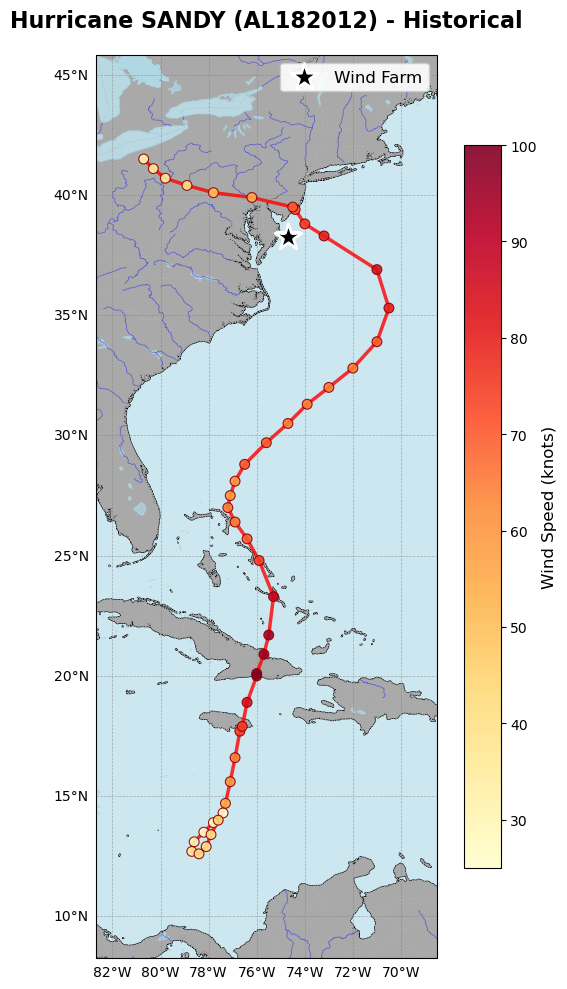

(<Figure size 1400x1000 with 2 Axes>,
 <GeoAxes: title={'center': 'Hurricane SANDY (AL182012) - Historical'}>)

In [6]:
# Step 4: Plot hurricane track with single method call
sandy.plot()

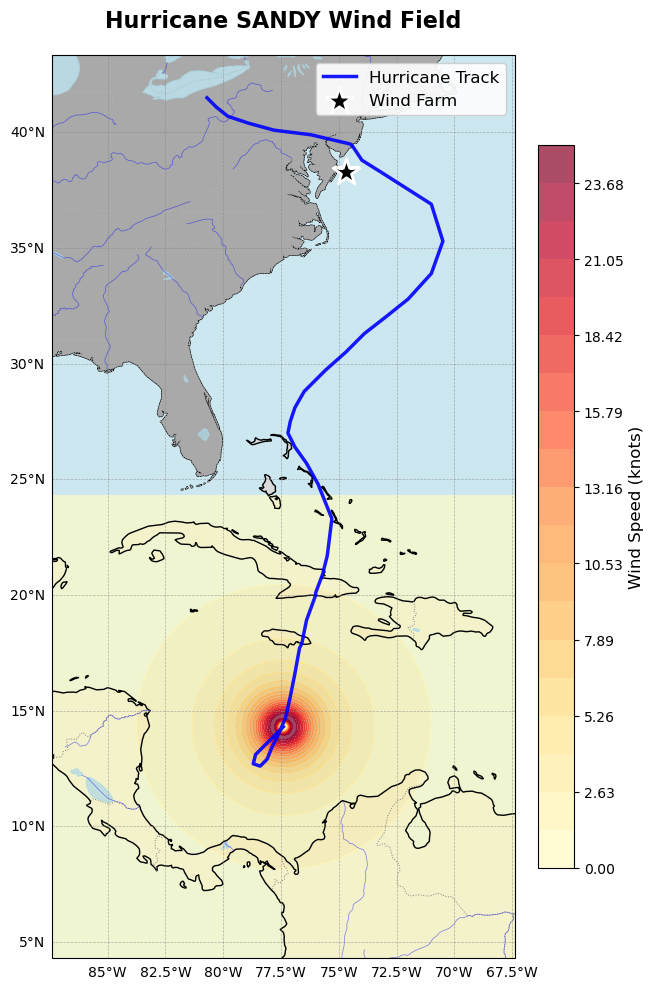

(<Figure size 1200x1000 with 2 Axes>,
 <GeoAxes: title={'center': 'Hurricane SANDY Wind Field'}>)

In [7]:
# Step 5: Generate detailed wind field plot
sandy.plot_wind_field()

In [8]:
# Step 6: Generate comprehensive report
report_file = sandy.generate_report()
print(f"Report saved as: {report_file}")

Hurricane report generated and saved to hurricane_report_AL182012.csv
Report saved as: hurricane_report_AL182012.csv


In [9]:
# Step 7: Get wind farm impact summary as dictionary
summary = sandy.get_wind_farm_summary()
print("Wind Farm Impact Summary:")
for key, value in summary.items():
    print(f"  {key}: {value}")

Wind Farm Impact Summary:
  closest_approach_km: 83.4944537897954
  max_wind_speed_knots: 86.83987994203557
  arrival_time: 2012-10-29 06:00:00
  max_intensity_knots: 100
  duration_hours: 234.0
  exceeds_cutout: True


# Additional Examples: Method Chaining and Advanced Usage

The new implementation supports method chaining and provides multiple convenient ways to work with hurricanes.

In [10]:
# Example 1: Method chaining for complete analysis
irene = (simulation.create_hurricane('AL092011')
         .analyze_wind_farm_impact())

irene.print_summary()


Hurricane IRENE (AL092011)
Type: Historical
Duration: 216.0 hours
Max Intensity: 105 knots
Data Points: 43

Wind Farm Impact:
  Closest Approach: 33.8 km
  Max Wind at Farm: 76.7 knots
  Arrival Time: 2011-08-27 12:00:00
  ⚠️  WARNING: Exceeds typical turbine cut-out speed!


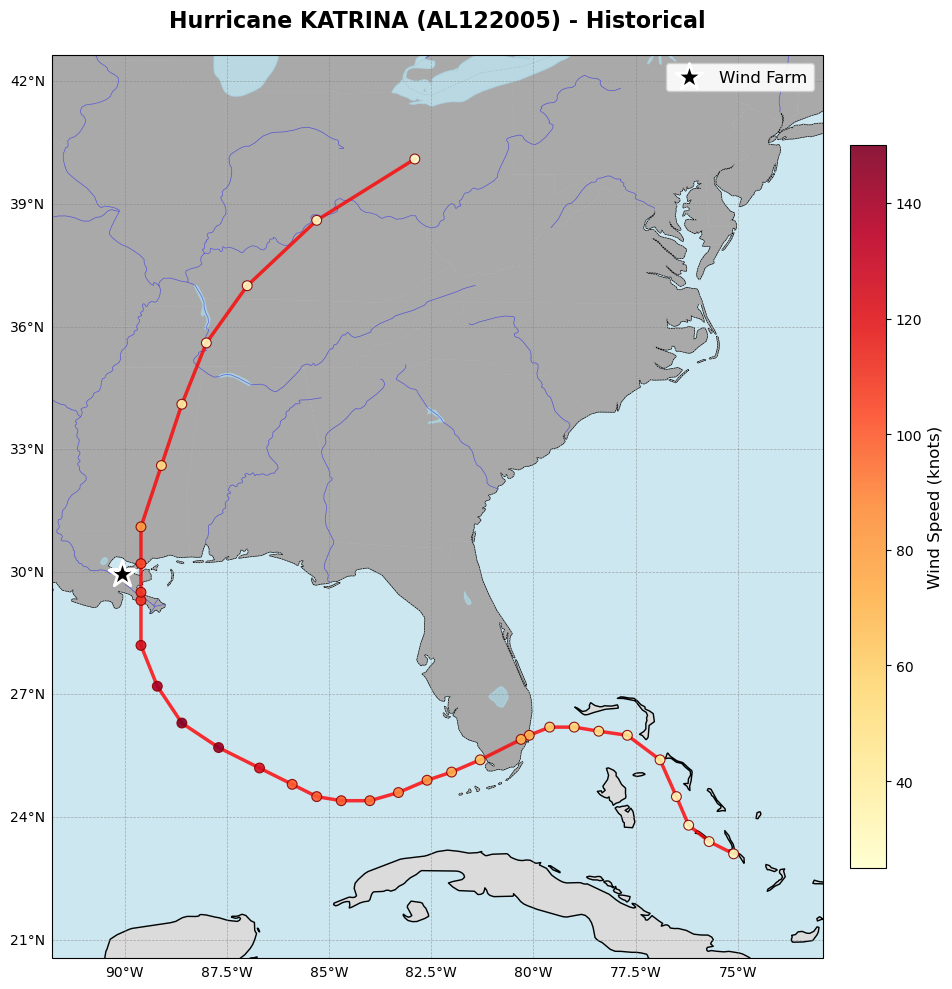

(<Figure size 1400x1000 with 2 Axes>,
 <GeoAxes: title={'center': 'Hurricane KATRINA (AL122005) - Historical'}>)

In [11]:
# Example 2: Create hurricane without wind farm, set it later
katrina = simulation.create_hurricane('AL122005')
katrina.set_wind_farm(29.9511, -90.0715)  # New Orleans coordinates
katrina.analyze_wind_farm_impact()
katrina.plot()

In [12]:
# Example 3: List available hurricanes with filters
recent_major_hurricanes = simulation.list_hurricanes(year=2017, min_intensity=111)
print("Major hurricanes from 2017:")
print(recent_major_hurricanes)

Major hurricanes from 2017:
      storm_id    name          start_date            end_date  max_intensity
1340  AL092017  HARVEY 2017-08-16 06:00:00 2017-09-02 12:00:00            115
1517  AL112017    IRMA 2017-08-30 00:00:00 2017-09-13 12:00:00            155
1590  AL122017    JOSE 2017-09-04 06:00:00 2017-09-25 06:00:00            135
1756  AL152017   MARIA 2017-09-16 12:00:00 2017-10-02 12:00:00            150


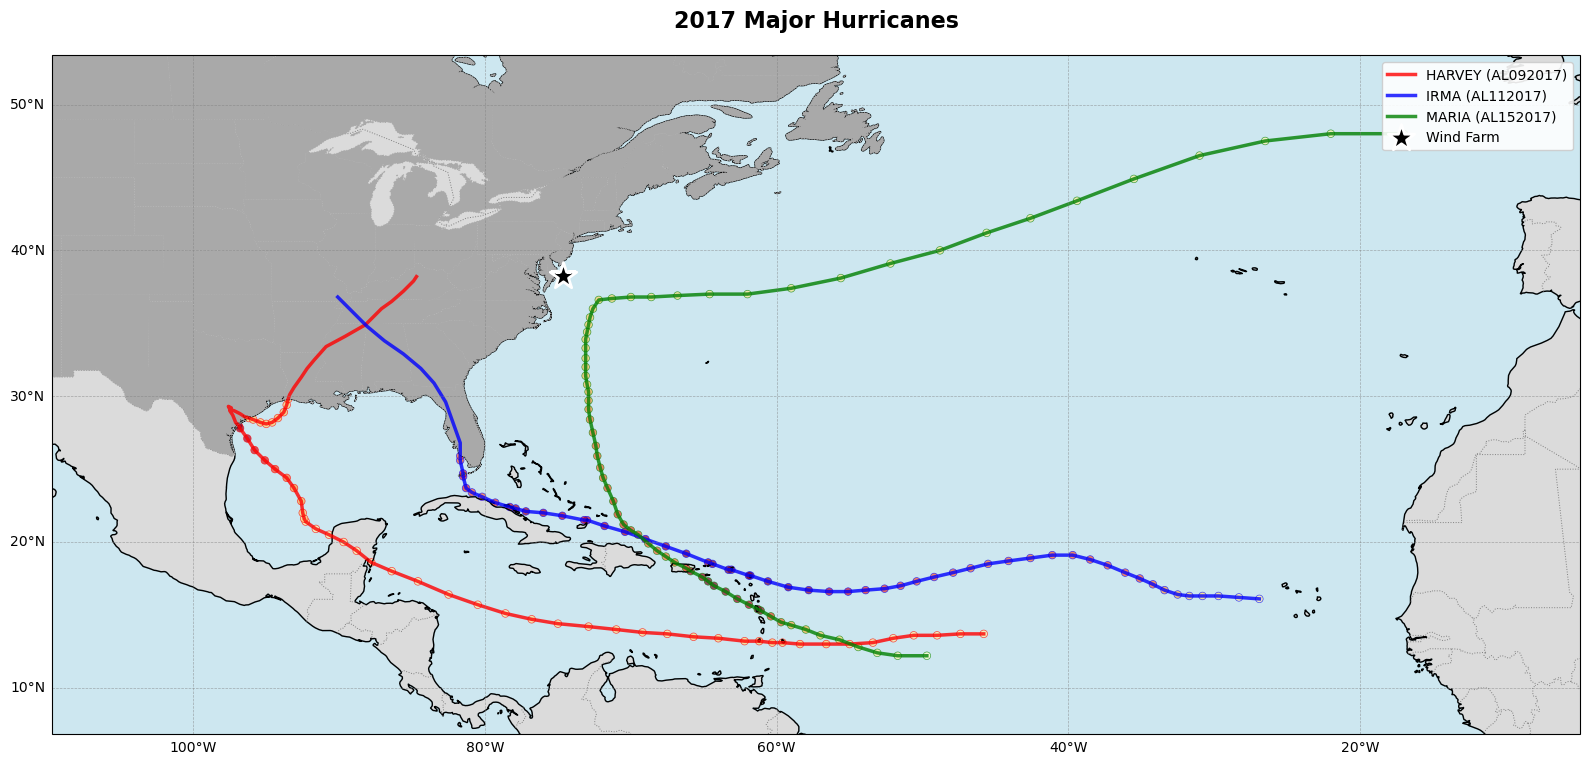

(<Figure size 1600x1200 with 1 Axes>,
 <GeoAxes: title={'center': '2017 Major Hurricanes'}>)

In [13]:
# Example 4: Compare multiple hurricanes
harvey = simulation.create_hurricane('AL092017').analyze_wind_farm_impact()
irma = simulation.create_hurricane('AL112017').analyze_wind_farm_impact()
maria = simulation.create_hurricane('AL152017').analyze_wind_farm_impact()

simulation.compare_hurricanes([harvey, irma, maria], title="2017 Major Hurricanes")

In [14]:
# Example 5: Batch analysis with summary
hurricanes_2012 = ['AL092012', 'AL182012']  # Isaac and Sandy
analyzed_hurricanes = []

for storm_id in hurricanes_2012:
    hurricane = (simulation.create_hurricane(storm_id)
                 .analyze_wind_farm_impact())
    analyzed_hurricanes.append(hurricane)
    print(f"\n{hurricane.name}:")
    summary = hurricane.get_wind_farm_summary()
    print(f"  Closest approach: {summary['closest_approach_km']:.1f} km")
    print(f"  Max wind at farm: {summary['max_wind_speed_knots']:.1f} knots")
    print(f"  Exceeds cut-out: {summary['exceeds_cutout']}")


ISAAC:
  Closest approach: 1621.4 km
  Max wind at farm: 1.4 knots
  Exceeds cut-out: False

SANDY:
  Closest approach: 83.5 km
  Max wind at farm: 86.8 knots
  Exceeds cut-out: True
